In [4]:
from keras.models import load_model
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from scipy.signal import savgol_filter
import topsispy as tp
from IPython.display import clear_output

             

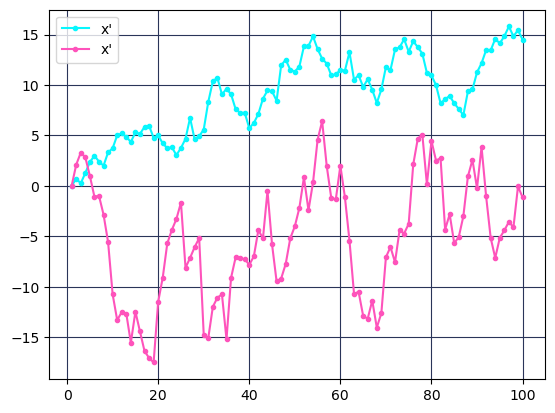

In [3]:
x1 = np.linspace(1, 100,100)
def f1(x):
    y = 0
    result = []
    for _ in x:
        result.append(y)
        y += np.random.normal(scale=1)
    return np.array(result)
def f2(x):
    y = 0
    result = []
    for _ in x:
        result.append(y)
        y += np.random.normal(scale=3)
    return np.array(result)
y1=f1(x1)
y2=f2(x1)
plt.plot(x1, y1, marker='.', label="x'", color='#08F7FE')
plt.plot(x1, y2, marker='.', label="x'", color='#FE53BB')

plt.grid(color='#2A3459')
plt.legend()


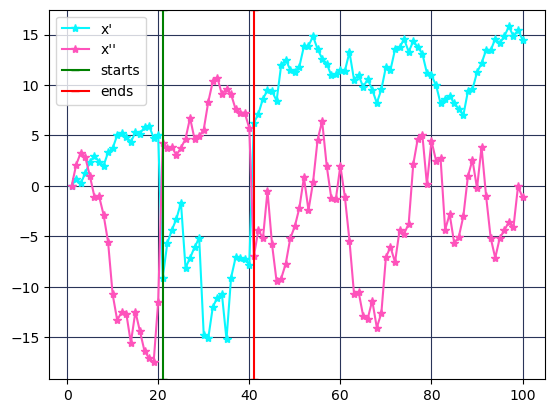

In [4]:
k=np.copy(y1[20:40])
y1[20:40]=y2[20:40]
y2[20:40]=k
plt.plot(x1, y1, marker='*', label="x'", color='#08F7FE')
plt.plot(x1, y2, marker='*', label="x''", color='#FE53BB')

plt.axvline(x = x1[20], marker='_',label = 'starts',color = 'green' )
plt.axvline(x = x1[40], marker='_', label = 'ends',color = 'red')
plt.grid(color='#2A3459')
plt.legend()

In [5]:
I=np.load("Im.npy",allow_pickle=True)
V=np.load("Vm.npy",allow_pickle=True)
T=np.load("Tm.npy",allow_pickle=True)
SOC=np.load("SOCm.npy",allow_pickle=True)
time=np.load("timem.npy",allow_pickle=True)

In [188]:
I1=np.load("I.npy",allow_pickle=True)
V1=np.load("V.npy",allow_pickle=True)
T1=np.load("T.npy",allow_pickle=True)
SOC1=np.load("SOC.npy",allow_pickle=True)

In [6]:
train_data=[I,V,T,SOC]

In [7]:
I=[]
V=[]
T=[]
SOC=[]
time=[]
for i in range(len(train_data[0])):
    for j in range(len(train_data[3][i])):
        I.append(train_data[0][i][j])
        V.append(train_data[1][i][j])
        T.append(train_data[2][i][j])
        SOC.append(train_data[3][i][j])
        #time.append(train_data[4][i][j])

In [8]:
df_train=pd.DataFrame({"I":I,"V":V,"T":T,"SOC":SOC})

In [194]:
mini,minv,mint,i=df_train.min()
maxi,maxv,maxt,i=df_train.max()

In [9]:
mini,minv,mint,maxi,maxv,maxt=np.load("min_max_soc.npy")

In [269]:
min_max=[mini,minv,mint,mintime,maxi,maxv,maxt,maxtime]
#np.save("min_max_ibra",min_max)

In [270]:
min_max

[-15.0005949768635,
 0.45556685702923,
 16.4348,
 -0.002420477573303225,
 8.009570727272726,
 3.67715008033726,
 38.146893,
 1.0]

In [10]:
df_train["I"]=(df_train["I"]-mini)/(maxi-mini)
df_train["V"]=(df_train["V"]-minv)/(maxv-minv)
df_train["T"]=(df_train["T"]-mint)/(maxt-mint)
#df_train["Time"]=(df_train["Time"]-mintime)/(maxtime-mintime)

In [11]:
def split_sequence(sequence, input_steps, output_steps):
    X = []
    y = []
    time=[]
    
    for i in range(len(sequence) - input_steps - output_steps + 1):
        X.append(np.array(sequence.iloc[i:i+input_steps, :3]))
        time.append(np.array(sequence.iloc[i:i+input_steps,3]))
        y.append(np.array(sequence.iloc[i+input_steps:i+input_steps+output_steps]["SOC"]))

    return X,y,time

In [12]:
X_train=[]
Y_train=[]
X_test=[]
Y_test=[]
input_step=100
output_step=25
X_train,Y_train,time=split_sequence(df_train,input_step,output_step)
#X_test,Y_test=split_sequence(df_test,input_step,output_step)

In [13]:
t=np.zeros((len(X_train),3,100))
for i in range(len(X_train)):
    for j in range(100):
        t[i][0][j]=X_train[i][j][0]
        t[i][1][j]=X_train[i][j][1]
        t[i][2][j]=X_train[i][j][2]
    

In [305]:
np.shape(t)

(165012, 3, 100)

In [14]:
X1=np.float32(X_train)
Y1=np.float32(Y_train)

In [15]:
model=load_model("soc_simple_prediction1.h5")

In [90]:
np.save("original_soc",Y1)

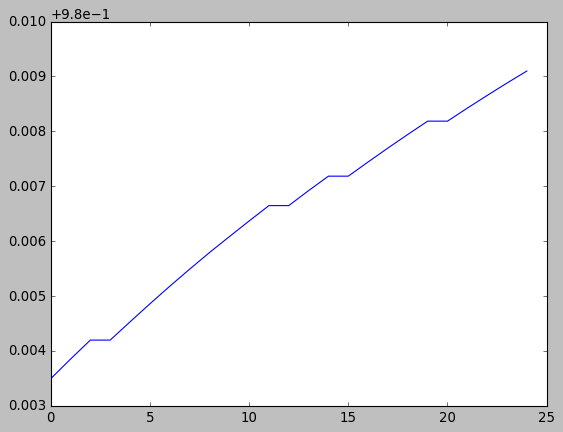

In [70]:
plt.plot(Y1[410])

In [87]:
y=model.predict(X1[100:101])

1/1 [==============================] - 0s 11ms/step


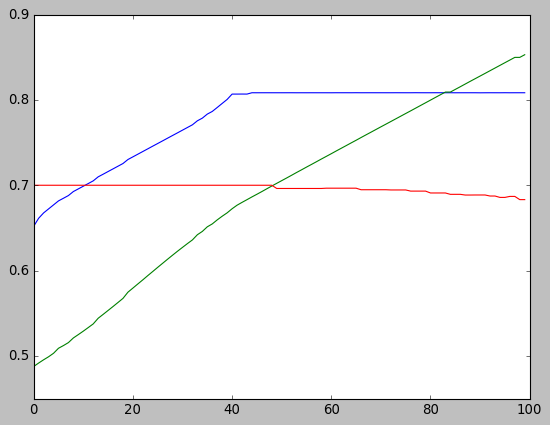

In [135]:
#plt.plot(y[0])
plt.plot(X1[0])

In [143]:
#timei=time[0]
input=X1[0]
population = X1[0:100]






In [144]:

def fitness_func(input, solution,dnr):
    d =  np.linalg.norm(input-solution)
    pr1=model.predict(np.reshape(input,(1,100,3)),verbose=0)
    pr2=model.predict(np.reshape(solution,(1,100,3)),verbose=0)
    correlation_matrix = np.corrcoef(pr1, pr2)
    y= np.linalg.norm(pr1-pr2)
    if (y==0):
        fitness=np.infty
    else:
        if (dnr==0):
            fitness=np.infty
        else:
            fitness =(d/y)+(1/dnr)*0
    
    return fitness,d,y,dnr,correlation_matrix[1, 1]

In [145]:
def nearest_neighbor_distance(p,c,j):
    min_d=np.inf
    index=0
    for i in range(len(p)):
        if(j!=i):
            d =  np.linalg.norm(p[i]-c)
            if(min_d>d):
                index=i
                min_d=d
    return min_d,index

In [146]:
def filtering(data):
    dt=[]
    while(len(data)!=0):
        dt.append(data[0])
        d=data[1:]
        df=[]
        for i in range(len(d)):
            if(np.linalg.norm(d[i]-dt[-1])!=0):
                df.append(d[i])
        data=df
    return dt
            
        
            

In [147]:
def selection(data,sign,weights):
    d=[]
    f=[]
    pro=[]
    validity=[]
    diversity=[]
    for i in tqdm(range(len(data)), desc="selection..."):
        d.append(np.reshape(data[i],(100,3)))
        min_d=nearest_neighbor_distance(data,data[i],i)
        pro.append(fitness_func(input,data[i],min_d[0])[1])
        validity.append(fitness_func(input,data[i],min_d[0])[2])
        diversity.append(fitness_func(input,data[i],min_d[0])[3])
        f.append(fitness_func(input,data[i],min_d[0])[0])
    matrix=np.transpose([validity,pro,diversity])   #validity(maximize),proximity(minimize),diversity(maximize)
    rank=tp.topsis(matrix, weights, sign)
    df=pd.DataFrame({"data":d,"f":rank[1]})
    df=df.sort_values(by=['f'],ascending=False)
    t=df.head(n=20)
    t=np.array(t['data'])
    t2=np.zeros((20,100,3))
    for i in range(20):
        for j in range(100):
            for k in range(3):
                t2[i][j][k]=t[i][j][k]
    return t2

In [148]:

def generate(data,prob=0.8):
    new_generation = []
    if(random.random()<prob):
        for l in tqdm(range(20), desc="generating..."):
            pi1 = random.randint(0, len(data) - 1)
            pi2 = random.randint(0, len(data) - 1)
            p1 = data[pi1]
            p2 = data[pi2]
            # Generate a random feature number 
            b=random.randint(0,99)
            f= [0,1,2]
            e=random.randint(b,min(b+20,100))
            for i in f:
                for j in range(b,e):
                    k = p1[j][i]
                    p1[j][i] = p2[j][i]
                    p2[j][i] = k
            
            new_generation.append(np.reshape(p1,(100,3)))
        
            
            new_generation.append(np.reshape(p2,(100,3)))
        
        
    return new_generation

In [156]:


def mutation(data, prob=0.2):
    muta = []
    if random.random() < prob:
        for j in tqdm(range(5), desc="mutation..."):
            individual = data[random.randint(0, len(data) - 1)]
            individual = np.reshape(individual, (100, 3))
            feature = random.choice([0, 1, 2])  # shape: (3,100)
            x = individual[feature]
            xl = 0
            xu = 1
            rand = random.random()

            # Randomly determine whether to push towards lower or upper boundary
            mutation_amount = random.uniform(-0.2, 0.2)  # Allow both decrease and increase
            x = np.clip(x + mutation_amount, 0, 1)  # Ensure values stay within [0, 1]
    
            individual[feature] = x
            muta.append(np.reshape(individual, (100, 3)))
           

    return muta

In [155]:
random.uniform(-0.2, 0.2)

0.11421810975610386

In [150]:
def evaluate(data):
    c=[]
    m=np.inf
    index=0
    for i in tqdm(range(len(data)), desc="evaluating..."):
        min_d=nearest_neighbor_distance(data,data[i],i)
        f=fitness_func(input,data[i],min_d[0])[0]
        if(f<m):
            m=f
            index=i
    return m,index

In [151]:
def is_convergent(array, tolerance=1e-6):
    a=0
    for i in range(1, len(array)):
        if abs(array[i] - array[i-1]) > tolerance:
            a=0
        else:
            a=a+1
    if(a>=50):
         return True
    else :
        return False
   

In [157]:

def conterfactual_generation(population,input):
    r=population
    a=[1,2,3]
    iteration=0
    index=0
    metric=0
    best_population=r
    previous_metric=np.inf
    sign = [1, -1, 1]
    weights=[0.3,0.6,0.10]
    while(not is_convergent(a) and iteration<=50 ):
        f=selection(r,sign,weights)
        
        r=generate(f)
    
        if(len(r)!=0):
            r=np.concatenate((f, r), axis=0)
        else:r=f
        m=mutation(r)
        if(len(m)!=0):
            r=np.concatenate((r, m), axis=0)
        d=[]
        f=[]
        pro=[]
        validity=[]
        diversity=[]
        for i in tqdm(range(len(r)), desc="filtering..."):
            d.append(r[i])
            min_d=nearest_neighbor_distance(r,r[i],i)
            pro.append(fitness_func(input,r[i],min_d[0])[1])
            validity.append(fitness_func(input,r[i],min_d[0])[2])
            diversity.append(fitness_func(input,r[i],min_d[0])[3])
            f.append(fitness_func(input,r[i],min_d[0])[0])
            
        matrix=np.transpose([validity,pro,diversity])  
        rank=tp.topsis(matrix, weights, sign)
        df=pd.DataFrame({"data":d,"f":rank[1]})
        df=df.sort_values(by=['f'],ascending=False)
        r=np.array(df['data'])
        r=filtering(r)
        metric,index=evaluate(r)
        if(metric<=previous_metric):
            previous_metric=metric
            best_population=r
        r=best_population    
        if(metric<=previous_metric):
            a.append(metric)
        else:a.append(previous_metric)
        iteration+=1
        clear_output(wait=True)
    return best_population,index,a

In [158]:
from time import time

In [159]:
t0=time()
cefs,index,a=conterfactual_generation(population,input)
t1 = time()

evaluating...: 100%|███████████████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 14.12it/s]


In [160]:
len(cefs),index

(20, 3)

In [161]:
(t1-t0)


1121.6848516464233

Text(0.5, 1.0, 'Evolution of fitness values over time')

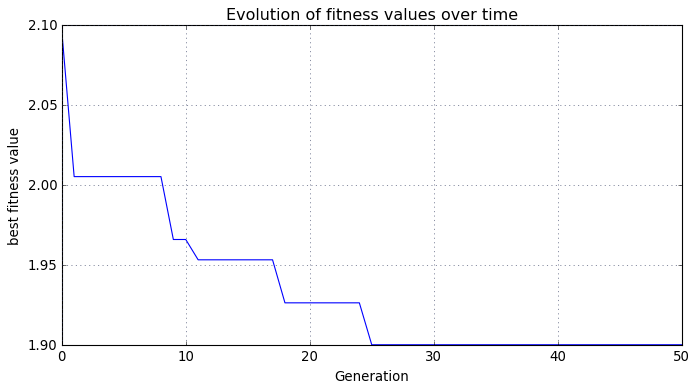

In [162]:
ax=plt.figure(figsize=(10, 5))
plt.plot(a[3:])
plt.xlabel('Generation')
plt.ylabel('best fitness value')
plt.grid(color='#2A3459')
ax.set_facecolor('white')
plt.title('Evolution of fitness values over time')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\pGF_near100.pdf')

In [31]:
np.save("counterfactulas",cefs)
np.save("original_data",input)
np.save("time",time)

In [53]:
cefs=np.load("counterfactulas.npy")
input=np.load("original_data.npy")
time=np.load("time.npy")
min_max=np.load("min_max_ibra.npy")

In [57]:
mini,minv,mint,mintime,maxi,maxv,maxt,maxtime=min_max

In [63]:
t=np.zeros((len(cefs),3,100))
for i in range(len(cefs)):
    for j in range(100):
        t[i][0][j]=cefs[i][j][0]*(maxi-mini)+mini
        t[i][1][j]=cefs[i][j][1]*(maxv-minv)+minv
        t[i][2][j]=cefs[i][j][2]*(maxt-mint)+mint
    

In [65]:
time=time*(maxtime-mintime)+mintime

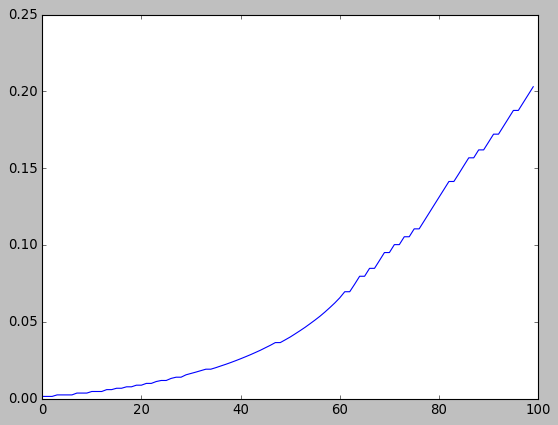

In [161]:
plt.plot(time[50])

In [160]:
np.save("time01",time[50])

In [62]:
np.save("original_data",t)

In [64]:
np.save("counterfactulas",cefs)

In [163]:
def distence(x1,x2):
       return  np.linalg.norm(x1-x2)
    

In [332]:
distence(cefs[0],input)

2.3746937172615925

In [333]:
nearest_neighbor_distance(cefs,cefs[0],0)

(2.1072312641201107, 10)

In [31]:

def prediction_d(x1,x2):
    pr1=model.predict(np.reshape(x1,(1,100,3)),verbose=0)
    pr2=model.predict(np.reshape(x2,(1,100,3)),verbose=0)
    y= np.linalg.norm(pr1-pr2)
    return y

In [334]:
prediction_d(cefs[0],input)

0.008004201

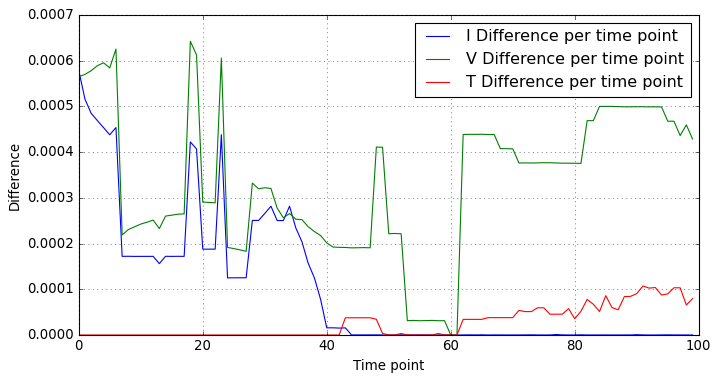

In [164]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
original_series=input
counterfactual_series=cefs[0]

# Assuming original_series and counterfactual_series are of shape (100, 3)
abs_per_feature = [np.sum(np.abs(original_series[:, i]-counterfactual_series[:, i]))/100 for i in range(3)]
ab= [np.abs(original_series[:, i]-counterfactual_series[:, i])/100 for i in range(3)]
dfi= ab[0]
dfv = ab[1]
dft = ab[2]
ax=plt.figure(figsize=(10, 5))
plt.plot(dfi, label='I Difference per time point')
plt.plot(dfv, label='V Difference per time point')
plt.plot(dft, label='T Difference per time point')
plt.xlabel('Time point')
plt.ylabel('Difference')
plt.grid(color='#2A3459')
plt.legend()
ax.set_facecolor('white')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\Vcurrent\\cf_best_fD.pdf')
plt.show()



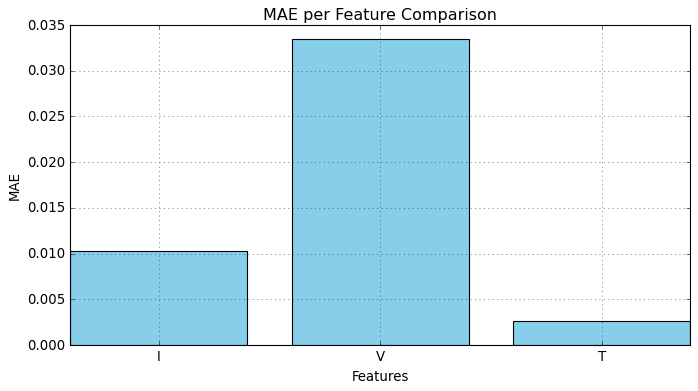

In [165]:

feature_names = ["I", "V","T"]
ax=plt.figure(figsize=(10, 5))
plt.bar(feature_names, abs_per_feature, color='skyblue')
plt.xlabel('Features')
plt.ylabel('MAE')
plt.grid(color='#2A3459')
plt.title('MAE per Feature Comparison')
ax.set_facecolor('white')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\Vcurrent\\cf_best_mae_perF.pdf')
plt.show()

In [166]:

def compare(x1,x2,time,f,name):
    names=["I","V","T"]
    feature=np.where(np.array(names) ==f)[0][0]
    d1=[x1[i][feature] for i in range(time,100)]
    d2=[x2[i][feature] for i in range(time,100)]
    plt.style.use("classic")
    colors = [
        '#08F7FE',  # teal/cyan
        '#FE53BB',  # pink
        '#F5D300',  # yellow
        '#00ff41',  # matrix green
    ]
    df = pd.DataFrame({'Original_data': list(d1),
                       'Counterfactual_data': list(d2)})
    fig, ax = plt.subplots(figsize=(10,5))
    df.plot(marker='.', color=colors, ax=ax)
    ax.grid(color='#2A3459')
    plt.xlabel('Time step', fontweight = 'bold', fontsize='large')
    plt.ylabel('Values', fontweight = 'bold', fontsize='large')
    plt.title('Comparision between the original and counterfactual values of feature '+f)
    plt.legend(loc='lower right')
    fig.set_facecolor('white')
    #plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\Vcurrent\\cf_best_'+name+f+'.pdf')
    plt.show()

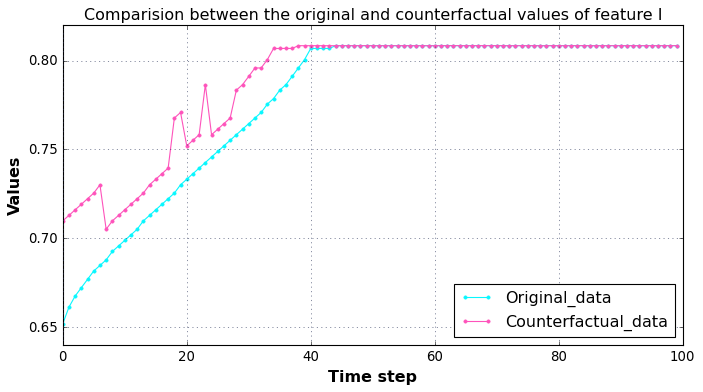

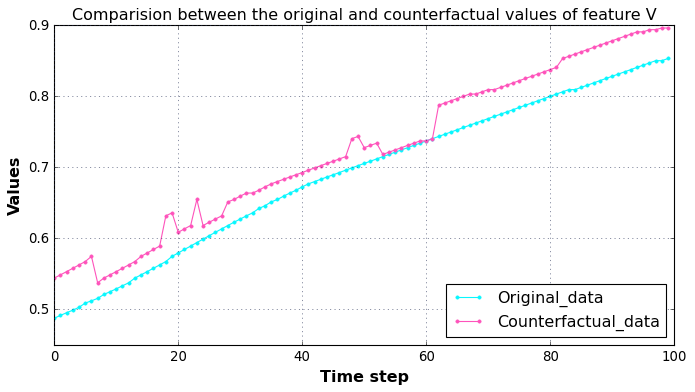

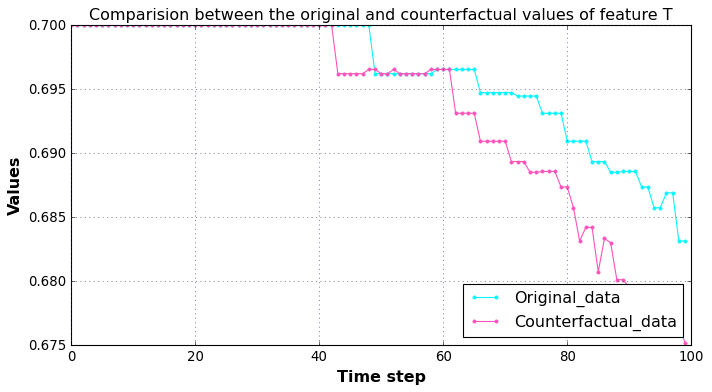

In [167]:
i=0
compare(input,cefs[i],0,"I","GA")
compare(input,cefs[i],0,"V","GA")
compare(input,cefs[i],0,"T","GA")

In [175]:
pr1=model.predict(np.reshape(cefs[19],(1,100,3)),verbose=0)
pr2=model.predict(np.reshape(input,(1,100,3)),verbose=0)

In [176]:
pr2

array([[0.04054569, 0.04159771, 0.04424296, 0.04528082, 0.04693004,
        0.04928548, 0.05162048, 0.05418213, 0.05584713, 0.05779389,
        0.06081859, 0.06261453, 0.06551471, 0.06661712, 0.07101416,
        0.07245226, 0.07589447, 0.07971989, 0.08200387, 0.08507128,
        0.08949918, 0.09362045, 0.09591203, 0.09973907, 0.10213099]],
      dtype=float32)

In [177]:
pr1

array([[0.05809448, 0.05932968, 0.06233254, 0.06356448, 0.06547074,
        0.06817323, 0.07078387, 0.07348961, 0.07539762, 0.07751118,
        0.08094309, 0.08276209, 0.08582595, 0.08697587, 0.09168404,
        0.09321667, 0.09679949, 0.10087942, 0.10312028, 0.10632866,
        0.11072836, 0.11490362, 0.11734533, 0.1210902 , 0.12342389]],
      dtype=float32)

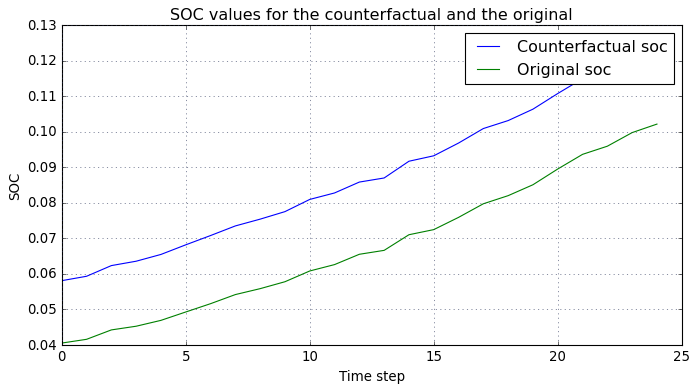

In [178]:
ax=plt.figure(figsize=(10, 5))
plt.plot(pr1[0],label="Counterfactual soc")
plt.plot(pr2[0],label="Original soc")
#plt.plot(Y1[410])
plt.xlabel('Time step')
plt.ylabel('SOC')
plt.grid(color='#2A3459')
plt.title('SOC values for the counterfactual and the original')
plt.legend()
ax.set_facecolor('white')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\Vcurrent\\prediction.pdf')

In [172]:
proximity_values = []
validity_values = []
diversity_values = []
r=cefs
for i in tqdm(range(len(r)), desc="analysing..."):
        min_d=nearest_neighbor_distance(r,r[i],i)
        proximity_values.append(fitness_func(input,r[i],min_d[0])[1])
        validity_values.append(fitness_func(input,r[i],min_d[0])[2])
        diversity_values.append(fitness_func(input,r[i],min_d[0])[3])
           

analysing...: 100%|████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.61it/s]


In [103]:
np.shape(cefs)

(20, 100, 3)

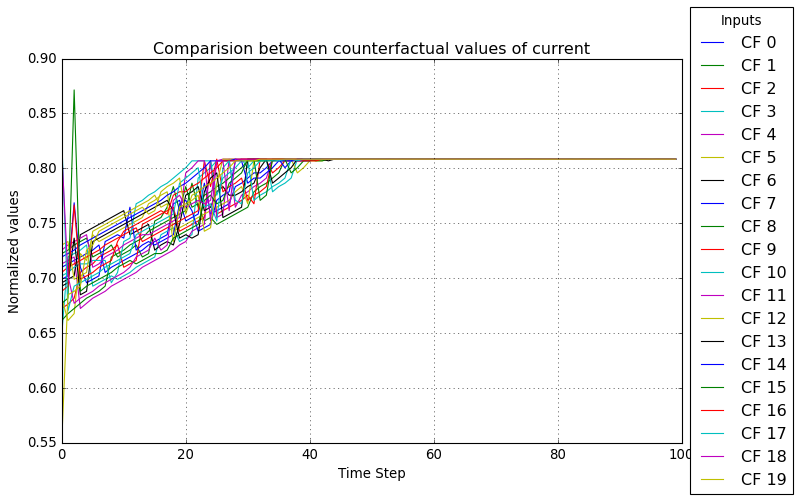

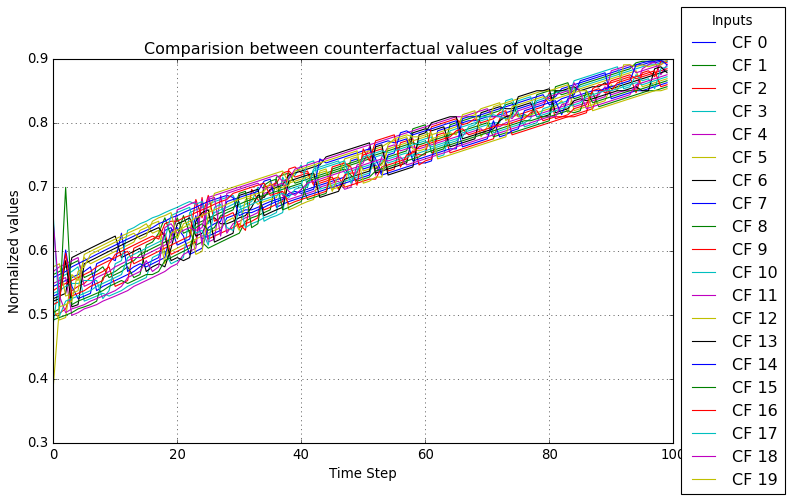

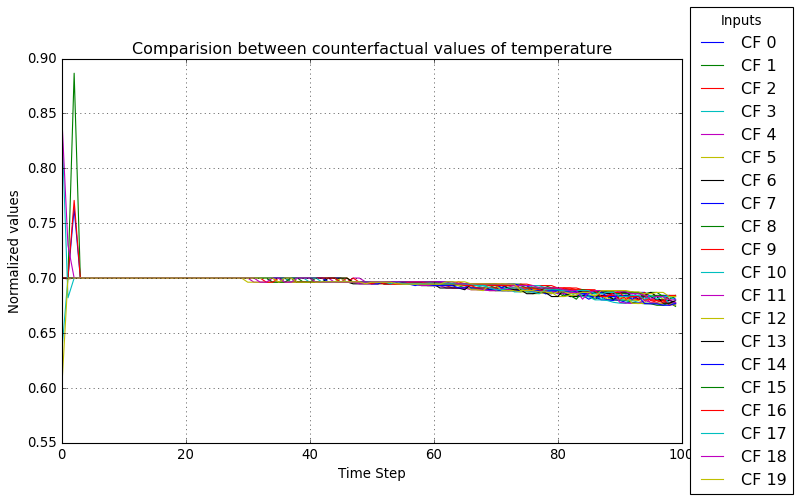

In [173]:
inputs = cefs
f=["current","voltage","temperature"]
# Plot for each feature
for feature_idx in range(3):
    ax=plt.figure(figsize=(10, 6))
    
    # Plot the specific feature for all inputs
    for i, input_data in enumerate(inputs):
        plt.plot(input_data[:, feature_idx], label=f'CF {i}')
    
    plt.title(f'Comparision between counterfactual values of {f[feature_idx]}')
    plt.xlabel('Time Step')
    plt.ylabel(f'Normalized values')
    ax.set_facecolor('white')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Inputs')
    plt.grid(True)
    #plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\Vcurrent\\CFC.pdf')
    plt.show()

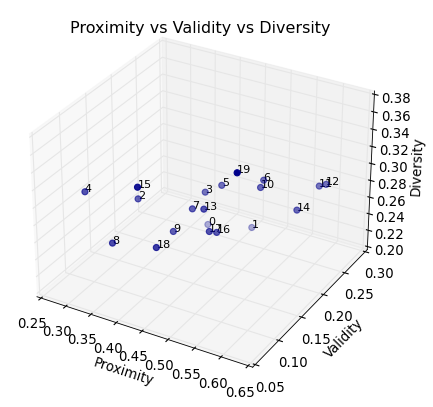

In [174]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the point (x, y, z)
ax.scatter(proximity_values, validity_values,  diversity_values, color='darkblue', s=30)  # s is the size of the point

for i in range(len(proximity_values)):
     ax.text(proximity_values[i], validity_values[i],  diversity_values[i], '%d' % i, color='black', fontsize=10)
# Set labels for axes
ax.set_xlabel('Proximity')
ax.set_ylabel('Validity')
ax.set_zlabel('Diversity')
fig.set_facecolor('white')

# Set the title
ax.set_title('Proximity vs Validity vs Diversity')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\Vcurrent\\GA_analysing.pdf')

# Display the plot
plt.show()

## NSGA2

In [1]:
!pip install deap


Defaulting to user installation because normal site-packages is not writeable


In [179]:
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification


In [182]:
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0, -1.0))
creator.create("Individual", np.ndarray, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.uniform, 0,1, 100)
#toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=3)
#toolbox.register("population", tools.initRepeat, list, toolbox.individual)
def init_individual(icls, points, index):
    individual = icls(points[index])
    return individual

# Custom function to initialize the population from the points array
def init_population(pcls, ind_init, points):
    return pcls(ind_init(creator.Individual, points, i) for i in range(len(points)))

# Register the custom population initialization function


# Register the individual and population initialization functions
toolbox.register("individual", init_individual, creator.Individual, population)
toolbox.register("population", init_population, list, init_individual, population)

ID=t[0]

def custom_crossover(ind1, ind2):
    # Define your custom crossover logic here
    # Example: Swap elements between ind1 and ind2
    if(np.ndim(ind1)==2 and np.ndim(ind2)==2):
        cxpoints = random.randint(1, min(np.shape(ind1)[1],np.shape(ind2)[1]) - 1)
        cxpointe =random.randint(cxpoints, min(np.shape(ind1)[1],np.shape(ind2)[1]) - 1)
        cxfe = random.randint(0, 3 - 1)
        ind1[0][cxpoints:cxpointe], ind2[0][cxpoints:cxpointe] = ind2[0][cxpoints:cxpointe], ind1[0][cxpoints:cxpointe]
        ind1[1][cxpoints:cxpointe], ind2[1][cxpoints:cxpointe] = ind2[1][cxpoints:cxpointe], ind1[1][cxpoints:cxpointe]
        ind1[2][cxpoints:cxpointe], ind2[2][cxpoints:cxpointe] = ind2[2][cxpoints:cxpointe], ind1[2][cxpoints:cxpointe]
    return ind1, ind2
def evaluate(individual):
    individual = np.array(individual).reshape(3,100)
    
    # Proximity (distance to the input data)
    proximity = np.linalg.norm(individual - ID)
    
    # Validity (model prediction difference)
    original_pred = model.predict(np.reshape(ID,(1,100,3)),verbose=0)[0]
    ctf_pred = model.predict(np.reshape(individual,(1,100,3)),verbose=0)[0]
    validity = np.linalg.norm(original_pred - ctf_pred)
    
    # Diversity (distance to the nearest neighbor in the population)
    
    if (len(population) > 1):
        reshaped_population = np.array([ind.reshape(3,100) for ind in population if not np.array_equal(ind, individual)])
        reshaped_individual = individual.reshape(3,100)
        distances = np.linalg.norm([reshaped_individual]-reshaped_population)
        diversity = np.min(distances)
    else:
        diversity = 0  # No other individuals to compare with

    return proximity, -validity, -diversity

def mutPolynomialBounded(individual, eta, low, up, indpb):
    feature=random.choice([0,1,2]) #shape: (3,100)
    if random.random() <= indpb:
            x = individual[feature]
            xl = 0
            xu = 1
            delta1 = x
            delta2 = xu - x 
            rand = random.random()
            mut_pow = 1.0 / (eta + 1)

            if rand <= 0.5:
                # Mutate towards the lower boundary
                delta = (xl - x) * random.uniform(0, 0.5)  # Add a fraction towards 0
            else:
                # Mutate towards the upper boundary
                delta = (xu - x) * random.uniform(0, 0.5)  # Add a fraction towards 1

            # Update the selected feature
            # Randomly determine whether to push towards lower or upper boundary
            mutation_amount = random.uniform(-0.2, 0.2)  # Allow both decrease and increase
            x = np.clip(x + mutation_amount, 0, 1)  # Ensure values stay within [0, 1]
           
            #x = min(max(x, xl), xu)
            individual[feature] = x
    return individual,
from functools import cmp_to_key

def sortNondominated(individuals, n):
    pareto_fronts = []
    dom_count = {i: 0 for i in range(n)}
    dominated_set = {i: [] for i in range(n)}
    fronts = []
    # Step 1: Dominance comparison
    for i in range(n):
        for j in range(n):
            if i != j:
                if dominates(individuals[i].fitness.values, individuals[j].fitness.values):
                    dominated_set[i].append(j)
                elif dominates(individuals[j].fitness.values, individuals[i].fitness.values):
                    dom_count[i] += 1
    
    # Step 2: Building fronts
    current_front = []
    for i in range(n):
        if dom_count[i] == 0:
            individuals[i].fitness.rank = 0
            current_front.append(i)
            
    pareto_fronts.append(current_front[:])
    front_idx = 0
    
    while len(pareto_fronts[front_idx]) > 0:
        next_front = []
        for i in pareto_fronts[front_idx]:
            for j in dominated_set[i]:
                dom_count[j] -= 1
                if dom_count[j] == 0:
                    individuals[j].fitness.rank = front_idx + 1
                    next_front.append(j)
        front_idx += 1
        pareto_fronts.append(next_front[:])
   
    # Step 3: Sorting within fronts (using crowding distance as secondary criterion if needed)
    for front in pareto_fronts[:-1]:
        front.sort(key=lambda x: individuals[x].fitness.values)  # Sort by fitness values
        
    return pareto_fronts[:-1]  # Exclude the last empty front

def dominates(fitness1, fitness2):
    
    """
    Check if fitness1 dominates fitness2 (all objectives are equal or better).
    """
    return all(f1 <= f2 for f1, f2 in zip(fitness1, fitness2)) and any(f1 < f2 for f1, f2 in zip(fitness1, fitness2))


def customSelectNSGA2(individuals, k):
    # Assign non-dominated ranks and crowding distances
    
    pareto_fronts =sortNondominated(individuals, len(individuals))
    
    selected = []
    current_rank = 0
    while len(selected) < k:
        if current_rank < len(pareto_fronts):
            front = pareto_fronts[current_rank]
            if len(selected) + len(front) <= k:
                selected.extend(front)
            else:
                # Sort by crowding distance within the front
                sorted_front = sorted(front, key=lambda x: np.sum(x.fitness.crowding_dist), reverse=True)
                remaining = k - len(selected)
                selected.extend(sorted_front[:remaining])
        else:
            break
        current_rank += 1
    
    return selected




toolbox.register("mate", custom_crossover)
toolbox.register("mutate", mutPolynomialBounded, eta=1.0, low=np.zeros((3, 100)), up=np.ones((3, 100)), indpb=0.2)
toolbox.register("select", customSelectNSGA2)
toolbox.register("evaluate", evaluate)


In [183]:
population = toolbox.population()

ngen = 50
cxpb = 0.7
mutpb = 0.2

for gen in tqdm(range(ngen), desc="generating..."):
     # Select parents for crossover
    
    parents = toolbox.select(population, len(population))
   
    p=[]
    for i in parents:
        p.append(population[i])
    ''''
    for i in range(len(p)):
        p[i][2]=savgol_filter(p[i][2],20,4)
        p[i][0]=savgol_filter(p[i][0],20,2)
        p[i][1]=savgol_filter(p[i][1],20,1)
    '''
    parents=p
    # Clone the selected individuals
    offspring = [toolbox.clone(ind) for ind in parents]
    
    # Apply crossover and mutation to offspring
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < cxpb:
            toolbox.mate(child1, child2)
            #del child1.fitness.values, child2.fitness.values
    
    for mutant in offspring:
        if random.random() < mutpb:
            toolbox.mutate(mutant)
            del mutant.fitness.values
   
    # Evaluate the fitness of the offspring
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Replace the current population with the offspring
    population[:] = offspring
    clear_output(wait=True)

# Extracting the Pareto front
pareto_front = tools.sortNondominated(population, len(population), first_front_only=False)[0]


generating...: 100%|███████████████████████████████████████████████████████████████████| 50/50 [01:20<00:00,  1.60s/it]


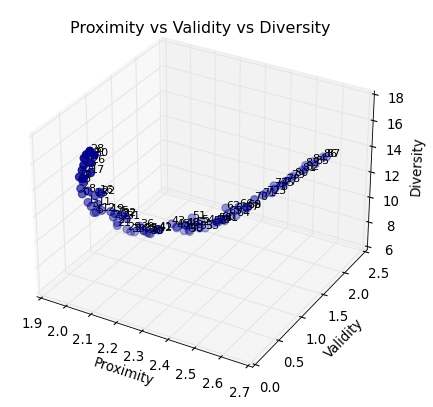

In [184]:
import matplotlib.pyplot as plt

proximity_values2 = [ind.fitness.values[0] for ind in pareto_front]
validity_values2 = [-ind.fitness.values[1] for ind in pareto_front]
diversity_values2 = [-ind.fitness.values[2] for ind in pareto_front]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the point (x, y, z)
ax.scatter(proximity_values2, validity_values2,  diversity_values2, color='darkblue', s=50)  # s is the size of the point

for i in range(len(proximity_values2)):
     ax.text(proximity_values2[i], validity_values2[i],  diversity_values2[i], '%d' % i, color='black', fontsize=10)
# Set labels for axes
ax.set_xlabel('Proximity')
ax.set_ylabel('Validity')
ax.set_zlabel('Diversity')
fig.set_facecolor('white')

# Set the title
ax.set_title('Proximity vs Validity vs Diversity')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\constant current\\NSGA2_analysing.pdf')

# Display the plot
plt.show()



In [422]:
np.shape(pareto_front),np.shape(ID)

((27, 100, 3), (3, 100))

In [185]:
t1=np.zeros((100,3))
for j in range(100):
        t1[j][0]=ID[0][j]
        t1[j][1]=ID[1][j]
        t1[j][2]=ID[2][j]

In [186]:
t2=np.array(pareto_front)


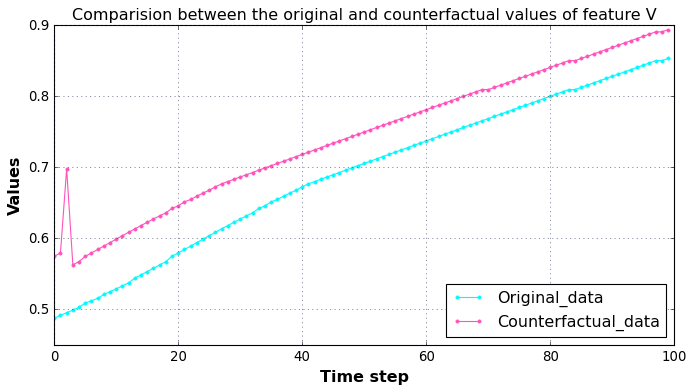

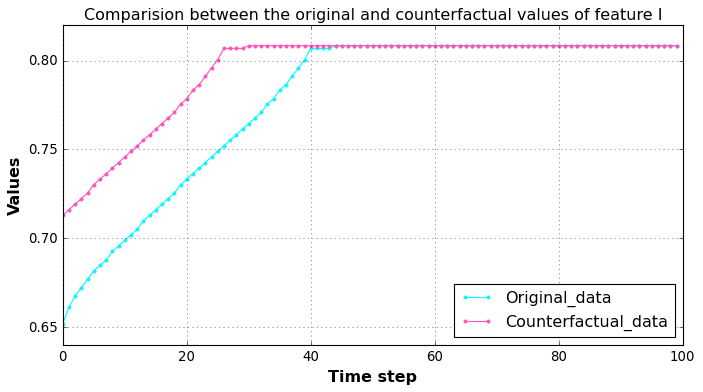

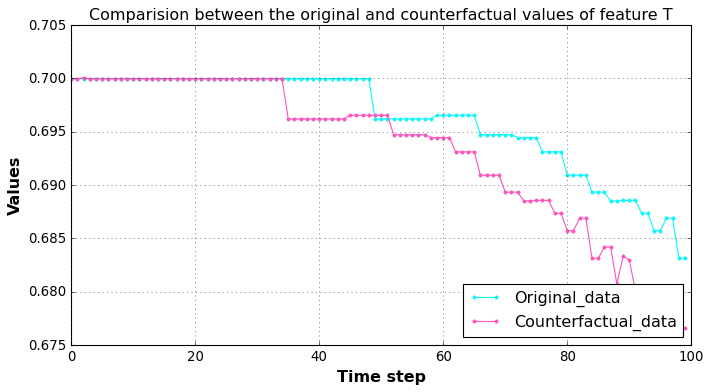

In [194]:
c=pareto_front[0]
s=0
compare(t1,c,s,"V","NSGA2")
compare(t1,c,s,"I","NSGA2")
compare(t1,c,s,"T","NSGA22")

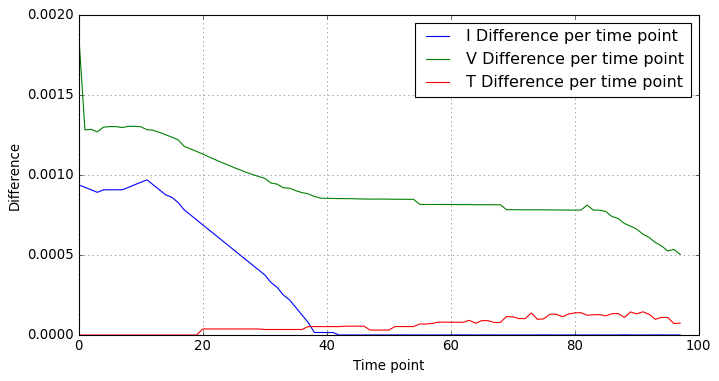

In [189]:
original_series=input
counterfactual_series=t2[32]

# Assuming original_series and counterfactual_series are of shape (100, 3)
abs_per_feature = [np.sum(np.abs(original_series[:, i]-counterfactual_series[:, i]))/100 for i in range(3)]
ab= [np.abs(original_series[:, i]-counterfactual_series[:, i])/100 for i in range(3)]
dfi= ab[0]
dfv = ab[1]
dft = ab[2]
ax=plt.figure(figsize=(10, 5))
plt.plot(dfi[2:], label='I Difference per time point')
plt.plot(dfv[2:], label='V Difference per time point')
plt.plot(dft[2:], label='T Difference per time point')
plt.xlabel('Time point')
plt.ylabel('Difference')
plt.grid(color='#2A3459')
plt.legend()
ax.set_facecolor('white')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\constant current\\cf_best_fD_NSGA2.pdf')
plt.show()

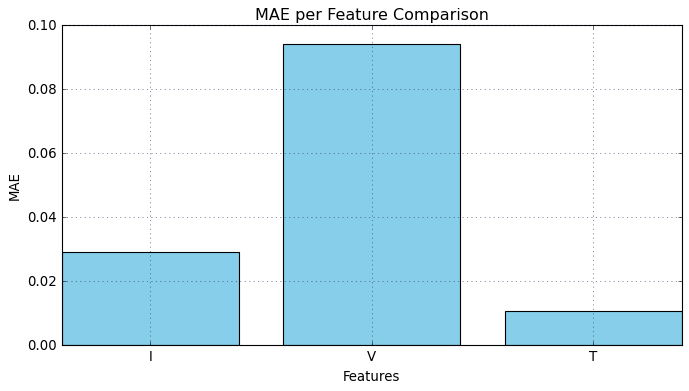

In [190]:
feature_names = ["I", "V","T"]
ax=plt.figure(figsize=(10, 5))
plt.bar(feature_names, abs_per_feature, color='skyblue')
plt.xlabel('Features')
plt.ylabel('MAE')
plt.grid(color='#2A3459')
plt.title('MAE per Feature Comparison')
ax.set_facecolor('white')
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\constant current\\cf_best_mae_perF_NSGA2.pdf')
plt.show()

In [191]:
pr1=model.predict(t2,verbose=0)
pr2=model.predict(np.reshape(input,(1,100,3)),verbose=0)

In [147]:
np.save("original_soc",pr2[0])

In [146]:
np.save("counterfactuals_nsg2_soc",pr1)

In [451]:
pr1[23]

array([0.80101866, 0.7965274 , 0.7920492 , 0.7839455 , 0.78003114,
       0.77454305, 0.76847595, 0.7647178 , 0.7566256 , 0.75160784,
       0.74652267, 0.73959565, 0.73466843, 0.7248264 , 0.7210709 ,
       0.7145062 , 0.70625407, 0.70227337, 0.6948634 , 0.6860486 ,
       0.68192637, 0.67176557, 0.6690589 , 0.66243255, 0.6625751 ],
      dtype=float32)

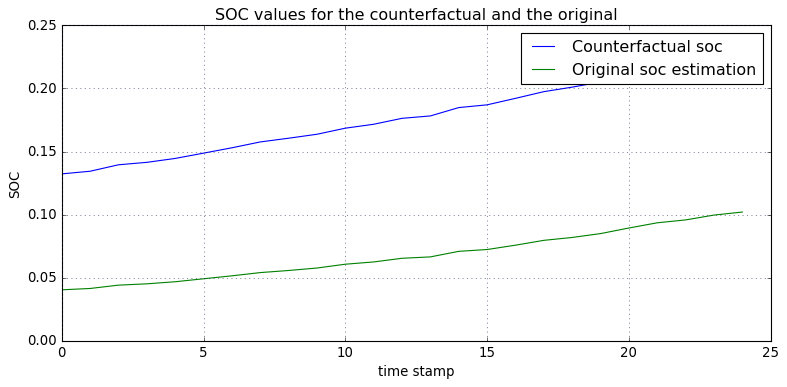

In [192]:
ax=plt.figure(figsize=(10, 5))
plt.plot(pr1[32],label="Counterfactual soc")
plt.plot(pr2[0],label="Original soc estimation")
#plt.plot(Y1[100],label="Original soc")
plt.xlabel('time stamp')
plt.ylabel('SOC')
plt.title('SOC values for the counterfactual and the original')
plt.legend()
ax.set_facecolor("white")
plt.grid(color='#2A3459')
plt.tight_layout()

# Save the figure as a PDF
#plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\constant current\\prediction2.pdf')


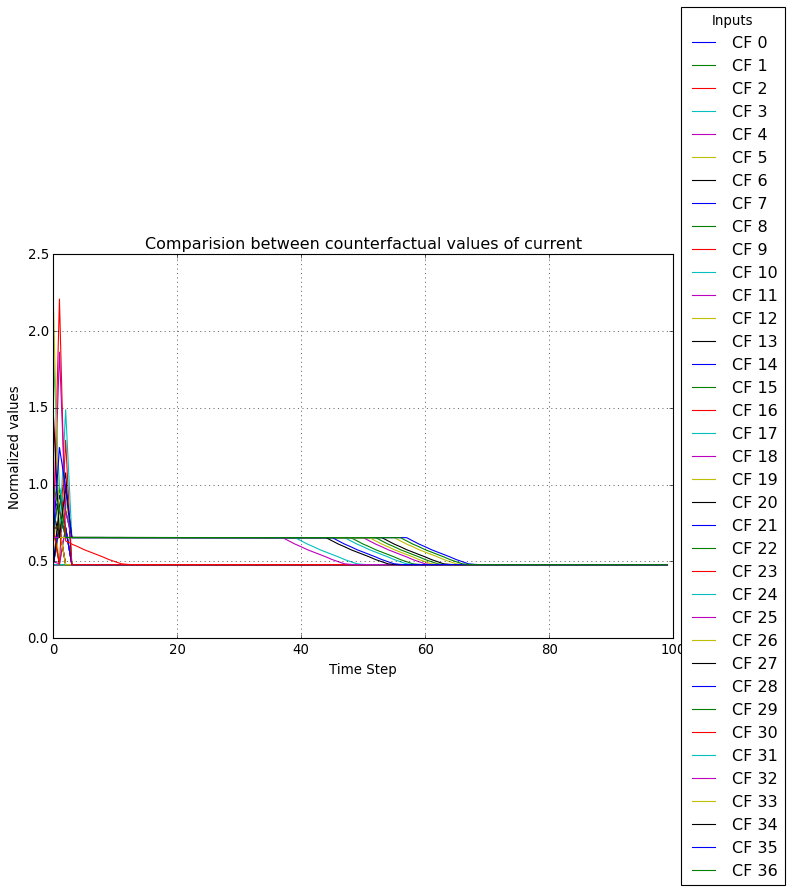

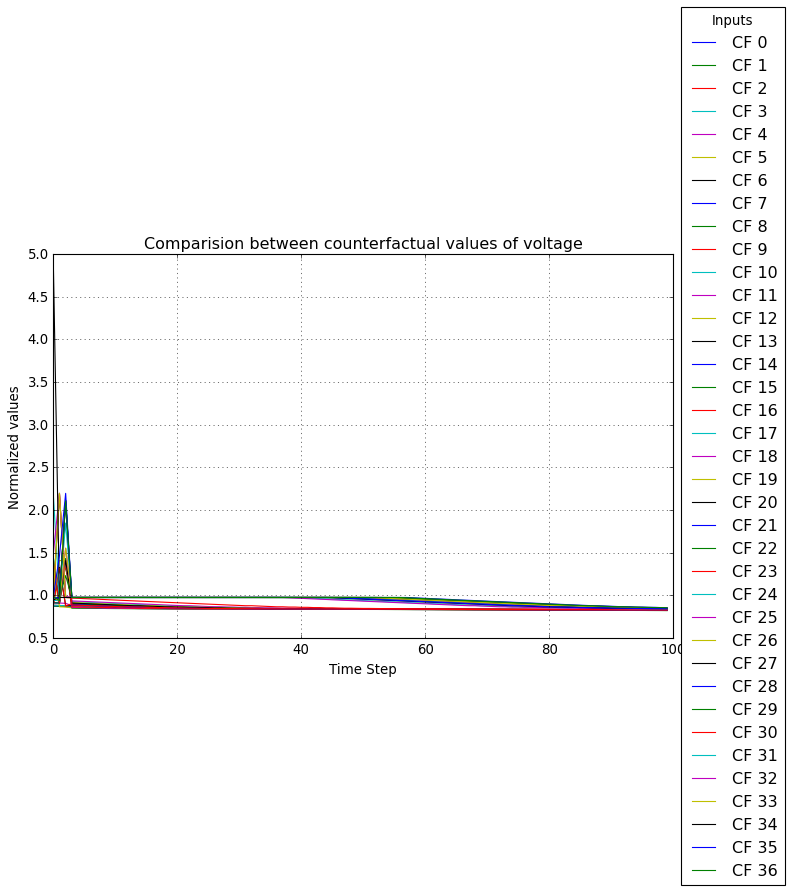

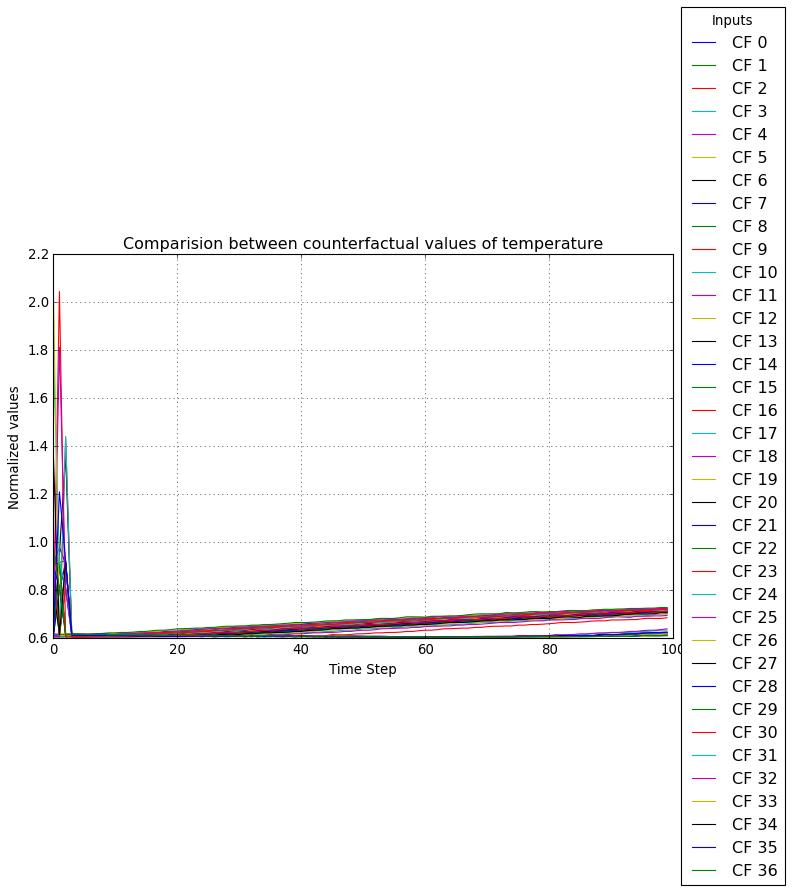

In [457]:
inputs = t2
f=["current","voltage","temperature"]
# Plot for each feature
for feature_idx in range(3):
    ax=plt.figure(figsize=(10, 6))
    
    # Plot the specific feature for all inputs
    for i, input_data in enumerate(inputs):
        plt.plot(input_data[:, feature_idx], label=f'CF {i}')
    
    plt.title(f'Comparision between counterfactual values of {f[feature_idx]}')
    plt.xlabel('Time Step')
    plt.ylabel(f'Normalized values')
    ax.set_facecolor('white')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Inputs')
    plt.grid(True)
    plt.savefig('C:\\Users\\sarbaoui01\\OneDrive - INSA Strasbourg\\Desktop\\Counterfactuals\\constant current\\CFC_NSGA2.pdf')
    plt.show()

In [149]:
t=np.zeros((len(pareto_front),3,100))
for i in range(len(cefs)):
    for j in range(100):
        t[i][0][j]=pareto_front[i][j][0]*(maxi-mini)+mini
        t[i][1][j]=pareto_front[i][j][1]*(maxv-minv)+minv
        t[i][2][j]=pareto_front[i][j][2]*(maxt-mint)+mint

In [150]:
np.save("counterfactulas",t)